# pleiodb reconstruction validation

Verifies the full pipeline from raw GWAS-VCF → pleiodb → reconstructed study-scale β/SE.

**Four panels**

| Panel | X | Y | Expected slope |
|-------|---|---|----------------|
| 1 | `ES_vcf` (canonical) | `beta_study = sqrt(var_y) × beta_norm` | 1.0 |
| 2 | `SE_vcf` | `se_study = sqrt(var_y) × se_norm` | 1.0 |
| 3 | `Z_vcf = ES_vcf / SE_vcf` | `Z_pleiodb` (stored) | 1.0 |
| 4 | Trait | `var_y` estimate vs `K·(1−K)` or `1.0` | informational |

Each panel reports slope, intercept, R² and flags PASS/FAIL at a 5 % slope tolerance
(1 % for Panel 3, where the z-score is stored directly).

**Prerequisites** – run in the `pleiodb` conda environment:
```
mamba run -n pleiodb jupyter nbconvert --to notebook --execute notebooks/validate_reconstruction.ipynb
```

In [14]:
from __future__ import annotations

import os
import csv
import json
import sys
import tempfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── locate repo root (notebook lives at repo_root/notebooks/) ─────────────
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src").exists(), f"Cannot locate src/ from {REPO_ROOT}"

# VCF paths in traits.tsv are relative to the repo root — chdir there so
# cyvcf2 and bcftools resolve them correctly.
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

from pleiodb import build_database, GWASDatabase
from pleiodb.alid import compress_allele

TEST_DATA = REPO_ROOT / "tests" / "test_data"
print(f"Repo root : {REPO_ROOT}")
print(f"CWD       : {Path.cwd()}")
print(f"Test data : {TEST_DATA}")

Repo root : /Users/gh13047/repo/pleiodb
CWD       : /Users/gh13047/repo/pleiodb
Test data : /Users/gh13047/repo/pleiodb/tests/test_data


## 1 · Build the test database

Uses the 500-variant, 5-trait test fixture in `tests/test_data/`.

In [15]:
DB_DIR = Path(tempfile.mkdtemp(prefix="pleiodb_validate_"))
DB_PATH = DB_DIR / "test.pleiodb"

build_database(
    output_dir=DB_PATH,
    variants_path=TEST_DATA / "variants_hg19.tsv",
    trait_tsv=TEST_DATA / "traits.tsv",
    chunk_shape=(64, 8),
    workers=2,
)
db = GWASDatabase.open(DB_PATH)
print(f"Built: V={db.V}  T={db.T}")
print(f"Traits: {list(db.traits['id'])}")
print(f"var_y : {[round(float(v), 4) for v in db.var_y]}")

Built: V=501  T=5
Traits: [np.str_('ukb-b-19953'), np.str_('ieu-a-7'), np.str_('ukb-b-10787'), np.str_('ieu-b-110'), np.str_('ieu-b-109')]
var_y : [0.9136, 2.4788, 0.3992, 0.2082, 0.1739]


## 2 · Load trait metadata (VCF paths, K values)

`K` is the case fraction for binary traits; absent for continuous traits.

In [16]:
with open(TEST_DATA / "traits.tsv") as fh:
    trait_rows = list(csv.DictReader(fh, delimiter="\t"))

trait_meta: dict[str, dict] = {}
for row in trait_rows:
    k_str = row.get("K", "").strip()
    n_str = row.get("N", "").strip()
    trait_meta[row["trait_id"]] = {
        "vcf_path": REPO_ROOT / row["vcf_path"],
        "K": float(k_str) if k_str else None,
        "N": int(n_str)   if n_str else None,
    }

for tid, m in trait_meta.items():
    kind = f"binary  K={m['K']}" if m["K"] is not None else "continuous"
    print(f"  {tid:<20}  {kind}")

  ukb-b-19953           continuous
  ieu-a-7               binary  K=0.34
  ukb-b-10787           continuous
  ieu-b-110             continuous
  ieu-b-109             continuous


## 3 · Extract ground truth from VCFs

For every variant in the database, we extract `ES`, `SE`, and `AF` from the GWAS-VCF
using the same allele-matching logic as the ingest pipeline:

- If `VCF_REF == A1` and `VCF_ALT == A2` → no flip
- If `VCF_REF == A2` and `VCF_ALT == A1` → flip: `ES_canonical = −ES_vcf`

`SE` is always positive; no sign change is applied.

In [17]:
def extract_vcf_records(vcf_path: Path, variants: np.ndarray) -> dict[str, dict]:
    """
    Open a GWAS-VCF and return per-ALID ground-truth statistics.

    Parameters
    ----------
    vcf_path : path to (bgzipped) GWAS-VCF
    variants : structured array from GWASDatabase.variants

    Returns
    -------
    dict mapping ALID → {"es": float, "se": float, "af": float}
    where *es* is the canonical effect size (sign-corrected for A2 orientation).
    """
    import cyvcf2

    # Build CHROM:POS → [(a1, a2, alid), …] lookup
    pos_lookup: dict[str, list] = {}
    for v in variants:
        alid = str(v["id"])
        chrom = str(v["chrom"])
        pos   = int(v["pos"])
        a1    = str(v["a1"])
        a2    = str(v["a2"])
        for key in (f"{chrom}:{pos}", f"chr{chrom}:{pos}"):
            pos_lookup.setdefault(key, []).append((a1, a2, alid))

    results: dict[str, dict] = {}
    vcf = cyvcf2.VCF(str(vcf_path))
    for rec in vcf:
        key = f"{rec.CHROM}:{rec.POS}"
        candidates = pos_lookup.get(key)
        if not candidates:
            continue
        vcf_ref = compress_allele(rec.REF)
        vcf_alt = compress_allele(rec.ALT[0]) if rec.ALT else None
        if vcf_alt is None:
            continue

        es_fmt = rec.format("ES")
        se_fmt = rec.format("SE")
        af_fmt = rec.format("AF")
        if es_fmt is None or se_fmt is None:
            continue

        es_val = float(es_fmt[0][0])
        se_val = float(se_fmt[0][0])
        af_val = float(af_fmt[0][0]) if af_fmt is not None else np.nan

        if se_val <= 0 or not (np.isfinite(es_val) and np.isfinite(se_val)):
            continue

        for a1, a2, alid in candidates:
            if   vcf_ref == a1 and vcf_alt == a2:
                flip = False
            elif vcf_ref == a2 and vcf_alt == a1:
                flip = True
            else:
                continue  # allele mismatch
            results[alid] = {
                "es": -es_val if flip else es_val,
                "se": se_val,
                "af": af_val,
            }
    vcf.close()
    return results

## 4 · Collect comparison data

For every matched variant-trait pair we record:

- `z_db` — z-score decoded from the database
- `z_vcf` — `ES_canonical / SE_vcf`
- `beta_study` — `beta_norm × sqrt(var_y[t])` (database, study scale)
- `es_vcf` — canonical effect size from VCF
- `se_study` — `se_norm × sqrt(var_y[t])` (database, study scale)
- `se_vcf` — standard error from VCF

In [18]:
rows: list[dict] = []
v_all = np.arange(db.V, dtype=np.int64)

for tid, meta in trait_meta.items():
    vcf_path = meta["vcf_path"]
    if not vcf_path.exists():
        print(f"  SKIP {tid}: VCF not found at {vcf_path}")
        continue

    t_idx    = int(db.trait_index([tid])[0])
    var_y_t  = float(db.var_y[t_idx])
    sqrt_vy  = float(np.sqrt(var_y_t)) if np.isfinite(var_y_t) and var_y_t > 0 else np.nan

    # Ground truth
    gt = extract_vcf_records(vcf_path, db.variants)

    # Database values — full column for this trait
    z_col          = db.zscore_trait(t_idx)                     # (V,)
    beta_col, se_col = db.beta_se_block(v_all, [t_idx])         # (V,1), (V,1)
    beta_col = beta_col[:, 0]                                   # (V,)
    se_col   = se_col[:, 0]                                     # (V,)

    n_matched = 0
    for v_idx_i in range(db.V):
        alid = str(db.variants["id"][v_idx_i])
        if alid not in gt:
            continue
        z_db_v = float(z_col[v_idx_i])
        if np.isnan(z_db_v):
            continue
        beta_n_v = float(beta_col[v_idx_i])
        se_n_v   = float(se_col[v_idx_i])
        if not (np.isfinite(beta_n_v) and np.isfinite(se_n_v)):
            continue

        gt_v = gt[alid]
        rows.append({
            "trait"      : tid,
            "alid"       : alid,
            "z_db"       : z_db_v,
            "z_vcf"      : gt_v["es"] / gt_v["se"],
            "beta_study" : beta_n_v * sqrt_vy,
            "es_vcf"     : gt_v["es"],
            "se_study"   : se_n_v   * sqrt_vy,
            "se_vcf"     : gt_v["se"],
        })
        n_matched += 1

    print(f"  {tid:<20}  var_y={var_y_t:.4f}  matched={n_matched}")

print(f"\nTotal comparison pairs: {len(rows):,}")

# Convert to numpy
z_db       = np.array([r["z_db"]       for r in rows])
z_vcf      = np.array([r["z_vcf"]      for r in rows])
beta_study = np.array([r["beta_study"] for r in rows])
es_vcf     = np.array([r["es_vcf"]     for r in rows])
se_study   = np.array([r["se_study"]   for r in rows])
se_vcf     = np.array([r["se_vcf"]     for r in rows])

  ukb-b-19953           var_y=0.9136  matched=490
  ieu-a-7               var_y=2.4788  matched=501
  ukb-b-10787           var_y=0.3992  matched=490
  ieu-b-110             var_y=0.2082  matched=501
  ieu-b-109             var_y=0.1739  matched=501

Total comparison pairs: 2,483


## 5 · Validation panels

Each scatter plot shows OLS fit (red) against the identity line (dashed black).
**PASS** = |slope − 1| < tolerance; **FAIL** otherwise.

**Panel 4 note** — for continuous traits the expected `var_y` is 1.0 (standardised phenotype).
For binary traits (e.g. CAD, `ieu-a-7`) most GWAS-VCFs report effects on the **log-OR scale**,
where `var_y` can substantially exceed `K·(1−K)`.  The `K·(1−K)` expectation is only exact
when betas are on the **liability scale**.  Panels 1–3 are the primary correctness checks;
Panel 4 is informational.


Figure saved → /Users/gh13047/repo/pleiodb/notebooks/validate_reconstruction.png


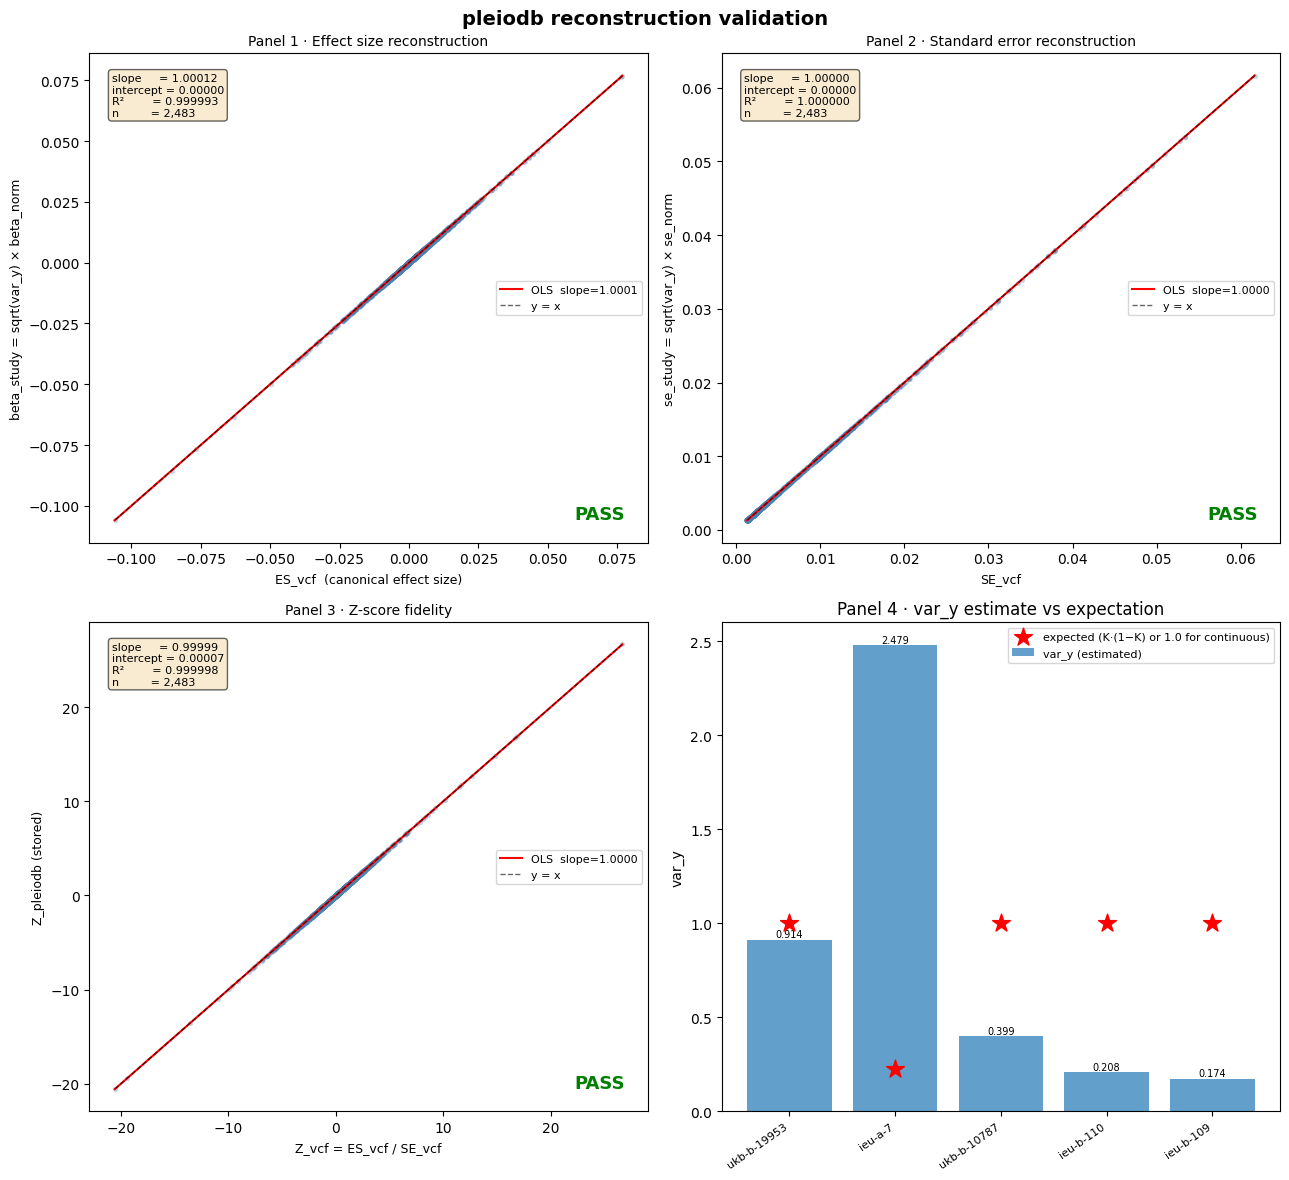

In [19]:
def _ols_panel(
    ax, x: np.ndarray, y: np.ndarray,
    xlabel: str, ylabel: str, title: str,
    tol: float = 0.05,
) -> dict:
    """Scatter + OLS on *ax*. Returns fit statistics."""
    mask = np.isfinite(x) & np.isfinite(y)
    xm, ym = x[mask], y[mask]

    slope, intercept, r, *_ = stats.linregress(xm, ym)
    R2 = r ** 2
    status = "PASS" if abs(slope - 1.0) < tol else "FAIL"

    ax.scatter(xm, ym, alpha=0.25, s=8, color="steelblue", rasterized=True)

    xl = np.array([xm.min(), xm.max()])
    ax.plot(xl, slope * xl + intercept, "r-",  lw=1.5, label=f"OLS  slope={slope:.4f}")
    ax.plot(xl, xl,                     "k--", lw=1.0, alpha=0.6, label="y = x")

    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title,   fontsize=10)
    ax.legend(fontsize=8)

    ax.text(
        0.04, 0.96,
        f"slope     = {slope:.5f}\nintercept = {intercept:.5f}\nR²        = {R2:.6f}\nn         = {mask.sum():,}",
        transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6),
    )
    ax.text(
        0.96, 0.04, status,
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=13, fontweight="bold",
        color="green" if status == "PASS" else "red",
    )
    return dict(slope=slope, intercept=intercept, R2=R2, n=int(mask.sum()), status=status)


# ── per-trait var_y vs expectation (Panel 4 data) ─────────────────────────
trait_ids_db    = [str(t) for t in db.traits["id"]]
var_y_estimated = np.array([float(db.var_y[i]) for i in range(db.T)])
var_y_expected  = np.array([
    trait_meta[tid]["K"] * (1 - trait_meta[tid]["K"])
    if trait_meta.get(tid, {}).get("K") is not None
    else 1.0
    for tid in trait_ids_db
])

# ── draw 2×2 figure ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
fit_results: dict[str, dict] = {}

# Panel 1 — beta_study vs ES_vcf
fit_results["panel1"] = _ols_panel(
    axes[0, 0],
    x=es_vcf,
    y=beta_study,
    xlabel="ES_vcf  (canonical effect size)",
    ylabel="beta_study = sqrt(var_y) × beta_norm",
    title="Panel 1 · Effect size reconstruction",
    tol=0.05,
)

# Panel 2 — se_study vs SE_vcf
fit_results["panel2"] = _ols_panel(
    axes[0, 1],
    x=se_vcf,
    y=se_study,
    xlabel="SE_vcf",
    ylabel="se_study = sqrt(var_y) × se_norm",
    title="Panel 2 · Standard error reconstruction",
    tol=0.05,
)

# Panel 3 — z_db vs z_vcf
fit_results["panel3"] = _ols_panel(
    axes[1, 0],
    x=z_vcf,
    y=z_db,
    xlabel="Z_vcf = ES_vcf / SE_vcf",
    ylabel="Z_pleiodb (stored)",
    title="Panel 3 · Z-score fidelity",
    tol=0.01,   # tighter: z is stored directly
)

# Panel 4 — var_y estimate vs expectation
ax4 = axes[1, 1]
x_pos = np.arange(db.T)
ax4.bar(x_pos, var_y_estimated, alpha=0.7, label="var_y (estimated)")
ax4.scatter(
    x_pos, var_y_expected,
    marker="*", s=180, c="red", zorder=5,
    label="expected (K·(1−K) or 1.0 for continuous)",
)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(trait_ids_db, rotation=35, ha="right", fontsize=8)
ax4.set_ylabel("var_y")
ax4.set_title("Panel 4 · var_y estimate vs expectation")
ax4.legend(fontsize=8)

for i, (tid, est, exp) in enumerate(zip(trait_ids_db, var_y_estimated, var_y_expected)):
    ax4.text(
        i, est + 0.002, f"{est:.3f}",
        ha="center", va="bottom", fontsize=7,
    )

fig.suptitle("pleiodb reconstruction validation", fontsize=14, fontweight="bold")
fig.tight_layout()
out_path = REPO_ROOT / "notebooks" / "validate_reconstruction.png"
fig.savefig(out_path, dpi=120)
print(f"Figure saved → {out_path}")
plt.show()

## 6 · Summary and assertions

The cell below prints the fit statistics for every panel and raises `AssertionError`
for any panel whose slope deviates beyond tolerance.  A clean run means the full
pipeline is consistent.

In [20]:
TOLERANCES = {"panel1": 0.05, "panel2": 0.05, "panel3": 0.01}

print("=" * 60)
print(f"{'Panel':<10} {'slope':>10} {'intercept':>12} {'R²':>10} {'n':>7}  status")
print("-" * 60)

failures = []
for panel, res in fit_results.items():
    print(
        f"{panel:<10} {res['slope']:>10.5f} {res['intercept']:>12.5f} "
        f"{res['R2']:>10.6f} {res['n']:>7,}  {res['status']}"
    )
    if res["status"] == "FAIL":
        failures.append(panel)

print("=" * 60)

# per-trait var_y summary
print("\nPanel 4 — per-trait var_y:")
print(f"  {'trait':<20} {'estimated':>10} {'expected':>10}")
for tid, est, exp in zip(trait_ids_db, var_y_estimated, var_y_expected):
    flag = "  ← binary" if trait_meta.get(tid, {}).get("K") is not None else ""
    print(f"  {tid:<20} {est:>10.4f} {exp:>10.4f}{flag}")

if failures:
    raise AssertionError(
        f"Validation FAILED for: {', '.join(failures)}.  "
        "Check the scatter plots above for details."
    )
else:
    print("\n✓ All panels PASS")

Panel           slope    intercept         R²       n  status
------------------------------------------------------------
panel1        1.00012      0.00000   0.999993   2,483  PASS
panel2        1.00000      0.00000   1.000000   2,483  PASS
panel3        0.99999      0.00007   0.999998   2,483  PASS

Panel 4 — per-trait var_y:
  trait                 estimated   expected
  ukb-b-19953              0.9136     1.0000
  ieu-a-7                  2.4788     0.2244  ← binary
  ukb-b-10787              0.3992     1.0000
  ieu-b-110                0.2082     1.0000
  ieu-b-109                0.1739     1.0000

✓ All panels PASS
